# Functional Connectivity Tutorial

**Goal:** Compute a parcel-level functional connectivity (FC) matrix from fMRIPrep preprocessed data.

```
fMRIPrep BOLD  ──►  confound regression  ──►  parcellation  ──►  correlation  ──►  Fisher z  ──►  CSV
```

---
**How this notebook is structured**

| Section | What to do |
|---------|------------|
| 1. Imports | Run as-is |
| 2. Configuration | Fill in your paths and settings |
| 3. Explore the helpers | Run `fc_help()` to see available functions |
| 4 – 9. Analysis | Each cell has a `# YOUR CODE HERE` block to complete |
| 10. Answer key | Scroll down for a complete working solution |

---
*Dependencies: see `README.md` for conda environment setup.*  
*Helper functions: see `fc_helpers.py` — call `fc_help("function_name")` for detailed docs.*

## 1. Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import plotting
from pathlib import Path

# Import all helper functions + the help browser
from fc_helpers import *

warnings.filterwarnings('ignore')
%matplotlib inline
print('Imports OK')

# nice for testing / debugging helper functions
import importlib, fc_helpers
importlib.reload(fc_helpers)
from fc_helpers import *

# Now confirm it's the right one
print(fc_helpers.__file__)

Imports OK
/pl/active/courses/2026_summer/neuroclass2026/software/tutorials/fc_helpers.py


## 2. Configuration

Set every path and parameter here. Nothing downstream should need editing.

In [2]:
# ── Subject / run identifiers ─────────────────────────────────────────────────
SUBJECT  = 'sub-XXX'
SESSION  = 'ses-XXX'
TASK     = 'rest'
RUN      = None            # set to 'run-01' if your data has run-level files
SPACE    = 'MNI152NLin6Asym'

# ── fMRIPrep derivatives root ─────────────────────────────────────────────────
FMRIPREP_DIR = '/path/to/fmriprep'

# ── Build file paths automatically from the identifiers above ────────────────
# -- vvv UNCOMMENT IF DATA IS BIDS DERIVATIVE FORMATTING!! vvv ────────────────
# _paths         = build_fmriprep_paths(
#     fmriprep_dir = FMRIPREP_DIR,
#     subject      = SUBJECT,
#     session      = SESSION,
#     task         = TASK,
#     run          = RUN,
#     space        = SPACE,
# )
# BOLD_PATH      = _paths['BOLD_PATH']
# CONFOUNDS_PATH = _paths['CONFOUNDS_PATH']
# EVENTS_PATH    = _paths['EVENTS_PATH']   # set to None for resting-state

# -- USE THIS SECTION IF YOU NEED TO MANUALLY POINT TO DATA PATHS ───────────────
BOLD_PATH      = '<insert path here>'
CONFOUNDS_PATH = '<insert path here>'
EVENTS_PATH    = '<insert path here>'   # set to None for resting-state

# ── Parcellation ──────────────────────────────────────────────────────────────
ATLAS        = 'schaefer'  # 'schaefer' | 'destrieux' | 'custom'
N_ROIS       = 200
YEO_NETWORKS = 7
ATLAS_PATH   = None        # '/path/to/my_atlas.nii.gz'

# ── Acquisition parameters ────────────────────────────────────────────────────
TR = 2.0   # repetition time in seconds

# ── Confound strategy ─────────────────────────────────────────────────────────
# 24-parameter motion model + tissue signals (conservative, standard for rest)
CONFOUND_COLS = [
    'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
    'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1',
    'rot_x_derivative1',   'rot_y_derivative1',   'rot_z_derivative1',
    'trans_x_power2',      'trans_y_power2',       'trans_z_power2',
    'rot_x_power2',        'rot_y_power2',         'rot_z_power2',
    'trans_x_derivative1_power2', 'trans_y_derivative1_power2',
    'trans_z_derivative1_power2', 'rot_x_derivative1_power2',
    'rot_y_derivative1_power2',   'rot_z_derivative1_power2',
    'white_matter', 'csf',
]
SCRUB_THRESHOLD = 0.5   # FD in mm; set to None to skip scrubbing


# ── Global signal regression (GSR) ───────────────────────────────────────────
# GSR removes the mean signal across all brain voxels before computing FC.
#
# Pros: reduces motion artefacts and respiratory noise; flattens the mean FC
#       distribution so anti-correlations become interpretable.
# Cons: mathematically forces the mean correlation toward zero, potentially
#       introducing spurious anti-correlations in genuinely positively-coupled
#       networks (Murphy et al. 2009; Power et al. 2017).
#
# Common practice:
#   Resting-state, no a-priori anti-correlation hypotheses → False (default)
#   Comparing to literature that used GSR                  → True
#   Task-fMRI                                              → False (task signal
#                                                            shares variance
#                                                            with global signal)
USE_GLOBAL_SIGNAL = False   # ← change to True to include GSR

# Apply the choice — do not edit below this line
if USE_GLOBAL_SIGNAL:
    if 'global_signal' not in CONFOUND_COLS:
        CONFOUND_COLS = CONFOUND_COLS + ['global_signal']
else:
    CONFOUND_COLS = [c for c in CONFOUND_COLS if c != 'global_signal']

print(f'  GSR       : {"ON  (global_signal included)" if USE_GLOBAL_SIGNAL else "OFF (global_signal excluded)"}'  )
    
    
# ── Bandpass Filter Parameters ─────────────────────────────────────────────────
LOWPASS_HZ = 0.1
HIGHPASS_HZ = 0.01

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR = os.getenv('OUTPUT_DIR', str(Path(FMRIPREP_DIR).parent / 'correlation_matrices'))
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Output filename ───────────────────────────────────────────────────────────
_sess_tag       = f'_{SESSION}' if SESSION else ''
OUTPUT_FILENAME = (f'{SUBJECT}{_sess_tag}_task-{TASK}'
                   f'_atlas-{ATLAS}{N_ROIS}_fc-fisherz.csv')

print('Configuration ready.')
print(f'  BOLD      : {BOLD_PATH}')
print(f'  Confounds : {CONFOUNDS_PATH}')
print(f'  Atlas     : {ATLAS} | N_ROIS={N_ROIS}')
print(f'  Output    : {OUTPUT_DIR}')


# ── Pipeline logger ───────────────────────────────────────────────────────────
init_log({
    'SUBJECT'          : SUBJECT,
    'SESSION'          : SESSION,
    'TASK'             : TASK,
    'RUN'              : RUN,
    'SPACE'            : SPACE,
    'BOLD_PATH'        : BOLD_PATH,
    'CONFOUNDS_PATH'   : CONFOUNDS_PATH,
    'EVENTS_PATH'      : EVENTS_PATH,
    'ATLAS'            : ATLAS,
    'N_ROIS'           : N_ROIS,
    'YEO_NETWORKS'     : YEO_NETWORKS,
    'ATLAS_PATH'       : ATLAS_PATH,
    'TR'               : TR,
    'SCRUB_THRESHOLD'  : SCRUB_THRESHOLD,
    'USE_GLOBAL_SIGNAL': USE_GLOBAL_SIGNAL,
    'CONFOUND_COLS'    : CONFOUND_COLS,
    'OUTPUT_DIR'       : OUTPUT_DIR,
    'OUTPUT_FILENAME'  : OUTPUT_FILENAME,
})

  [paths] WARNING: 2 files match — using first.
          Pass **filters (e.g. res="2") to disambiguate:
            sub-MSC01_ses-func01_task-motor_run-01_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz
            sub-MSC01_ses-func01_task-motor_run-02_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz
  [paths] WARNING: 2 files match — using first.
          Pass **filters (e.g. res="2") to disambiguate:
            sub-MSC01_ses-func01_task-motor_run-01_desc-confounds_timeseries.tsv
            sub-MSC01_ses-func01_task-motor_run-02_desc-confounds_timeseries.tsv
  [paths] WARNING: 2 files match — using first.
          Pass **filters (e.g. res="2") to disambiguate:
            sub-MSC01_ses-func01_task-motor_run-01_events.tsv
            sub-MSC01_ses-func01_task-motor_run-02_events.tsv
  [paths] BOLD        : /scratch/alpine/amhe4269/openneuro/ds000224/derivatives/fmriprep/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-motor_run-01_space-MNI152NLin6Asym_res-2_desc-prep

## 3. Explore the Helper Functions

Run the cells below to see what's available. Each helper has detailed documentation.

In [ ]:
# List all available helper functions
fc_help()

In [ ]:
# Read detailed docs for any function before you use it, e.g.:
fc_help('load_confounds')

In [ ]:
# Try a few others:
# fc_help('get_parcellation')
# fc_help('extract_time_series')
# fc_help('compute_fc_matrix')
# fc_help('plot_fc_matrix')

---
## 4. Inspect Motion Quality

Before any analysis, check the framewise displacement (FD) trace to understand data quality.

**Function:** `plot_fd_trace(confounds_path, scrub_threshold, t_r)`  
**Returns:** `fig, mean_fd, pct_scrubbed`

👉 *Call `fc_help('plot_fd_trace')` for full parameter documentation.*

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# Plot the FD trace using plot_fd_trace().
# Pass: CONFOUNDS_PATH, SCRUB_THRESHOLD, and TR
# Capture the three return values: fig, mean_fd, pct_scrubbed



# ─────────────────────────────────────────────────────────────────────────────
plt.show()
# After running: does this run look usable? What is the mean FD?

## 5. Load Confound Regressors

**Function:** `load_confounds(confounds_path, cols, scrub_threshold)`  
**Returns:** `confounds_array` (shape T × regressors), `scrubbed_idx`

The `CONFOUND_COLS` list is already built from your Configuration cell, with `global_signal` included or excluded based on `USE_GLOBAL_SIGNAL`.

**Should you use global signal regression (GSR)?**

| | Include GSR (`True`) | Exclude GSR (`False`, default) |
|-|----------------------|-------------------------------|
| **Effect** | Forces mean FC → 0; anti-correlations become interpretable | Preserves the true mean FC level across the brain |
| **Use when** | Comparing to GSR literature; resting-state with strong motion | Task fMRI; testing anti-correlation hypotheses |
| **Caution** | Can introduce spurious anti-correlations (Murphy et al. 2009) | Higher sensitivity to global noise sources |

👉 *Call `fc_help('load_confounds')` to see full confound strategy options.*

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# Load the confound regressors using load_confounds().
# Pass: CONFOUNDS_PATH, CONFOUND_COLS, SCRUB_THRESHOLD
# Store results as: confounds_array, scrubbed_idx



# ─────────────────────────────────────────────────────────────────────────────
# After running: how many regressors do you have? Any columns skipped?

## 6. Load the Parcellation

**Function:** `get_parcellation(atlas, n_rois, yeo_networks, atlas_path)`  
**Returns:** `atlas_img` (NIfTI), `roi_labels` (list of str)

👉 *Call `fc_help('get_parcellation')` for atlas options.*

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# Load the parcellation using get_parcellation().
# Use the ATLAS, N_ROIS, YEO_NETWORKS, and ATLAS_PATH variables from CONFIG.
#  - Note: get_parcellation() is flexible to accept a predefined or custom parcellaiton
# Store results as: atlas_img, roi_labels



# ─────────────────────────────────────────────────────────────────────────────
# Visualise the parcellation on a brain
plotting.plot_roi(
    atlas_img,
    title        = f'{ATLAS.capitalize()}-{N_ROIS} parcellation',
    display_mode = 'z',
    cut_coords   = 6,
    colorbar     = True,
)
plt.show()

🛑 **check that your parcellation map and fMRI time series data are in the same space!** Are both aligned to the same anatomical template? Are they both in the same resolution (e.g. 2 mm)? Are they both aligned in RAS or LAS orientation? Do not proceed unless you are confident your mask and input data are aligned correctly!

## 7. Check BOLD ↔ Atlas Alignment

Before extracting time series you must verify that the BOLD image and the parcellation atlas are **in the same template space**. If they are not aligned, the masker will still run — but the extracted time series will be anatomically meaningless.

**Functions:**
- `check_alignment(bold_path, atlas_img, t_r)` — prints a five-point numeric report
- `plot_alignment(bold_path, atlas_img)` — overlays atlas borders on the mean BOLD

**What to look for:**
| Check | Pass means... | Fail means... |
|-------|--------------|---------------|
| Voxel size | Same resolution — no resampling needed | Masker will resample automatically |
| Affine origin | Images share the same world-coordinate anchor | Possible template mismatch |
| Field of view | All atlas parcels fall inside the BOLD volume | Some parcels → NaN time series |
| Orientation | Axis directions agree (both RAS, etc.) | Flip or rotation error |
| Space label | Both headers claim the same coordinate space | Hard mismatch — do not proceed |

👉 *Call `fc_help('check_alignment')` or `fc_help('plot_alignment')` for full docs.*

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# 7a. Run the numeric alignment check using check_alignment().
#     Pass: BOLD_PATH, atlas_img, and TR
#     Store the result as: report



# ─────────────────────────────────────────────────────────────────────────────
# After running: did all checks pass? Is resampling needed?
# If space_label FAILED — stop here and fix the template space mismatch.


In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# 7b. Visually verify alignment using plot_alignment().
#     Pass: BOLD_PATH and atlas_img
#     Store the result as: display
#
# What to look for: atlas parcel borders should follow gyral anatomy.
# If parcels appear shifted or at the wrong scale, the images are misaligned.



# ─────────────────────────────────────────────────────────────────────────────
# Optionally save the overlay:
# display.savefig('./fc_output/alignment_check.png', dpi=150)


## 8. Extract Parcel Time Series

**Function:** `extract_time_series(bold_path, atlas_img, confounds_array, t_r, ...)`  
**Returns:** `time_series` (shape T × n_rois)

This step resamples the atlas, averages voxels within each parcel, regresses confounds, and bandpass-filters — all in one call.

👉 *Call `fc_help('extract_time_series')` for filtering parameter details.*

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# Extract parcel time series using extract_time_series().
# Pass: BOLD_PATH, atlas_img, confounds_array, TR
# Keep the default bandpass settings (low_pass=0.1, high_pass=0.01)
# Store result as: time_series



# ─────────────────────────────────────────────────────────────────────────────
# Visualise a sample of extracted time series
fig = plot_time_series(time_series, TR, n_rois=8, labels=roi_labels)
plt.show()
# After running: does the shape match your expectations? (T × N_ROIS)

## 9. Compute the FC Matrix

**Function:** `compute_fc_matrix(time_series, fisher_z=True)`  
**Returns:** `fc_matrix` (shape n_rois × n_rois)

Pearson correlation between every pair of parcel time series, then Fisher r → z transform.

👉 *Call `fc_help('compute_fc_matrix')` to understand why Fisher z is needed.*

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# Compute the FC matrix using compute_fc_matrix().
# Use fisher_z=True (always recommended for group-level analysis).
# Store result as: fc_matrix



# ─────────────────────────────────────────────────────────────────────────────
# Print summary statistics
stats = summarise_fc(fc_matrix, label=f'{SUBJECT} | {TASK}')

## 10. Visualise and Save

**Functions:** `plot_fc_matrix(...)` and `save_fc_matrix(...)`

👉 *Call `fc_help('plot_fc_matrix')` or `fc_help('save_fc_matrix')` for options.*

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# 9a. Plot the FC matrix using plot_fc_matrix().
#     Pass: fc_matrix, labels=roi_labels, and a descriptive title.



# ─────────────────────────────────────────────────────────────────────────────
plt.show()

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# 9b. Save the FC matrix to OUTPUT_DIR using save_fc_matrix().
#     Build a descriptive filename that includes SUBJECT, TASK, and ATLAS.
#     Tip: f'{SUBJECT}_task-{TASK}_atlas-{ATLAS}{N_ROIS}_fc-fisherz.csv'



# ─────────────────────────────────────────────────────────────────────────────
# Verify the file was saved correctly
# check = pd.read_csv(out_path, index_col=0)
# print(f'Saved CSV shape: {check.shape}')   # should be (N_ROIS, N_ROIS)

---
## 🔬 Checkpoint — Questions to Consider

Before moving to the answer key, think through these:

1. **Motion quality** — What was the mean FD? What percentage of volumes were scrubbed? Would you use this run in a group analysis?
2. **Confound strategy** — Why do we use derivatives and quadratics of the motion parameters, not just the 6 raw parameters?
3. **Bandpass filtering** — Why is filtering applied *after* confound regression, not before?
4. **Fisher z** — If you average FC matrices across subjects, why must you do so in z-space and not r-space?
5. **Atlas choice** — How would your results change if you used Schaefer-400 instead of Schaefer-200?

---

# ✅ Answer Key

---
> **Scroll past here only after completing the exercise above.**
> 
> The cells below show a complete, working solution for each step.
---

### AK-1. Motion Quality

In [ ]:
# ── ANSWER KEY: Step 4 — Inspect FD trace ────────────────────────────────────
fig, mean_fd, pct_scrubbed = plot_fd_trace(
    confounds_path   = CONFOUNDS_PATH,
    scrub_threshold  = SCRUB_THRESHOLD,
    t_r              = TR,
)
plt.show()
print(f'Mean FD: {mean_fd:.3f} mm  |  {pct_scrubbed:.1f}% of volumes scrubbed')

### AK-2. Load Confounds

In [ ]:
# ── ANSWER KEY: Step 5 — Load confound regressors ────────────────────────────
# CONFOUND_COLS already has global_signal included/excluded per USE_GLOBAL_SIGNAL.
# Flip the flag in Configuration and re-run from cell 4 to switch strategies.

confounds_array, scrubbed_idx = load_confounds(
    confounds_path  = CONFOUNDS_PATH,
    cols            = CONFOUND_COLS,
    scrub_threshold = SCRUB_THRESHOLD,
)
print(f'Confound matrix : {confounds_array.shape}  (T × regressors)')
print(f'Scrubbed volumes: {scrubbed_idx}')
print(f'GSR included    : {USE_GLOBAL_SIGNAL}')
print(f'Columns used    : {CONFOUND_COLS}')

### AK-3. Load Parcellation

In [ ]:
# ── ANSWER KEY: Step 6 — Load parcellation ───────────────────────────────────
atlas_img, roi_labels = get_parcellation(
    atlas        = ATLAS,
    n_rois       = N_ROIS,
    yeo_networks = YEO_NETWORKS,
    atlas_path   = ATLAS_PATH,
)
print(f'Atlas image shape  : {atlas_img.shape}')
print(f'Number of ROI labels: {len(roi_labels)}')
print(f'First 5 labels: {roi_labels[:5]}')

plotting.plot_roi(
    atlas_img,
    title        = f'{ATLAS.capitalize()}-{N_ROIS} parcellation',
    display_mode = 'z',
    cut_coords   = 6,
    colorbar     = True,
)
plt.show()

### AK-4. Alignment QC

In [ ]:
# ── ANSWER KEY: Step 7 — Check BOLD ↔ atlas alignment ────────────────────────

# 7a. Numeric report
report = check_alignment(BOLD_PATH, atlas_img, t_r=TR)

# Interpret results
if not report['space_label']['pass']:
    raise RuntimeError(
        'Space label mismatch: BOLD and atlas are in different coordinate '
        'spaces. Verify that your fMRIPrep output is in MNI152 space and '
        'that your atlas is also in MNI152.'
    )

if not report['field_of_view']['pass']:
    print('WARNING: some atlas parcels fall outside the BOLD field of view.\n'
          'These parcels will produce NaN time series. Consider using a '
          'smaller atlas or checking your BOLD coverage.')

if report['needs_resampling']:
    print('Note: voxel sizes differ — NiftiLabelsMasker will resample '
          'automatically (resampling_target="labels").')

print(f'\nOverall alignment: {"PASS" if report["overall_pass"] else "ISSUES FOUND"}')


In [ ]:
# ── ANSWER KEY: Step 7b — Visual overlay ─────────────────────────────────────

# Axial slices (default) — most informative for cortical coverage
display = plot_alignment(
    bold_path    = BOLD_PATH,
    atlas_img    = atlas_img,
    n_cuts       = 6,
    display_mode = 'z',
)

# Save overlay for records
import os
display.savefig(os.path.join(OUTPUT_DIR, f'{SUBJECT}_alignment_check.png'), dpi=150)
print('Overlay saved.')

# Interpretation guide
print()
print('What to look for:')
print('  ✓ GOOD — atlas parcel borders follow gyral anatomy in the BOLD background')
print('  ✗ BAD  — parcels appear shifted, rotated, or at wrong scale')
print('  ✗ BAD  — parcels appear entirely outside the brain')


### AK-5. Extract Time Series

In [ ]:
# ── ANSWER KEY: Step 7 — Extract parcel time series ──────────────────────────
time_series = extract_time_series(
    bold_path       = BOLD_PATH,
    atlas_img       = atlas_img,
    confounds_array = confounds_array,
    t_r             = TR,
    standardize     = True,
    detrend         = True,
    low_pass        = 0.10,
    high_pass       = 0.01,
)
print(f'Time series shape: {time_series.shape}  (T × ROIs)')

fig = plot_time_series(
    time_series,
    t_r    = TR,
    n_rois = 8,
    labels = roi_labels,
    title  = f'{SUBJECT} — sample parcel time series (first 8 ROIs)',
)
plt.show()

### AK-6. Compute FC Matrix

In [ ]:
# ── ANSWER KEY: Step 8 — Compute FC matrix ───────────────────────────────────
fc_matrix = compute_fc_matrix(time_series, fisher_z=True)
print(f'FC matrix shape: {fc_matrix.shape}')

stats = summarise_fc(fc_matrix, label=f'{SUBJECT} | {ATLAS}-{N_ROIS} | {TASK}')

### AK-7. Visualise the FC Matrix

In [ ]:
# ── ANSWER KEY: Step 9a — Plot ────────────────────────────────────────────────
fig = plot_fc_matrix(
    fc_matrix,
    labels  = roi_labels,
    title   = f'{SUBJECT} — {TASK.capitalize()} FC | '
              f'{ATLAS.capitalize()}-{N_ROIS} (Fisher z)',
    cmap    = 'RdBu_r',
    figsize = (10, 9),
    output_path = os.path.join(OUTPUT_DIR, f'{SUBJECT}_fc_matrix.png'),
)
plt.show()

### AK-8. Save FC Matrix

In [ ]:
# ── ANSWER KEY: Step 9b — Save ────────────────────────────────────────────────
fname = f'{SUBJECT}_task-{TASK}_atlas-{ATLAS}{N_ROIS}_fc-fisherz.csv'
if SESSION:
    fname = f'{SUBJECT}_{SESSION}_task-{TASK}_atlas-{ATLAS}{N_ROIS}_fc-fisherz.csv'

out_path = save_fc_matrix(
    fc_matrix  = fc_matrix,
    labels     = roi_labels,
    output_dir = OUTPUT_DIR,
    filename   = fname,
)

# Verify round-trip
check = pd.read_csv(out_path, index_col=0)
print(f'Verified CSV shape : {check.shape}')
print(f'Column names match : {list(check.columns[:3])} ...')

In [4]:
from nilearn import datasets
import nibabel as nib
import numpy as np

data = datasets.fetch_atlas_schaefer_2018(n_rois=N_ROIS, yeo_networks=YEO_NETWORKS, resolution_mm=2)
atlas_img = nib.load(data.maps)
labels_raw = list(data.labels)
if labels_raw and isinstance(labels_raw[0], bytes):
    labels_raw = [l.decode() for l in labels_raw]

unique_ints = sorted(int(v) for v in np.unique(atlas_img.get_fdata()))

print(f'len(labels_raw) : {len(labels_raw)}')
print(f'len(unique_ints): {len(unique_ints)}')
print(f'condition match : {len(labels_raw) == len(unique_ints)}')  # must be True for fix to trigger
print(f'0 in unique_ints: {0 in unique_ints}')
print()
print(f'labels_raw[:3]  : {labels_raw[:3]}')
print(f'labels_raw[-3:] : {labels_raw[-3:]}')
print(f'unique_ints[:3] : {unique_ints[:3]}')
print(f'unique_ints[-3:]: {unique_ints[-3:]}')

[fetch_atlas_schaefer_2018] Dataset found in /home/amhe4269/nilearn_data/schaefer_2018
len(labels_raw) : 201
len(unique_ints): 201
condition match : True
0 in unique_ints: True

labels_raw[:3]  : ['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2']
labels_raw[-3:] : ['7Networks_RH_Default_pCunPCC_1', '7Networks_RH_Default_pCunPCC_2', '7Networks_RH_Default_pCunPCC_3']
unique_ints[:3] : [0, 1, 2]
unique_ints[-3:]: [198, 199, 200]


### AK-9. Complete Workflow (single cell)

The entire pipeline in one compact block — useful as a loop template for multi-subject analysis.

[fetch_atlas_schaefer_2018] Dataset found in /home/amhe4269/nilearn_data/schaefer_2018
  [atlas] NOTE: dropped background label "Background" (atlas value 0)
  [atlas] Schaefer-200 (Yeo-7): 200 parcels
  [confounds] Scrubbing 0 volumes (FD > 0.5 mm)
  [confounds] Matrix shape: (188, 26)  (T × regressors)
[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x150a46c4dd00>
[NiftiLabelsMasker.wrapped] Finished fit
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract('/pl/active/cowell/studies/monovis/analysis/fmriprep/sub-108/ses-S1/func/sub-108_ses-S1_task-monovis_dir-pa_run-01_space-MNI152NLin6Asym_desc-preproc_bold.nii.gz', 
{ 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'keep_masked_labels': False,
  'l

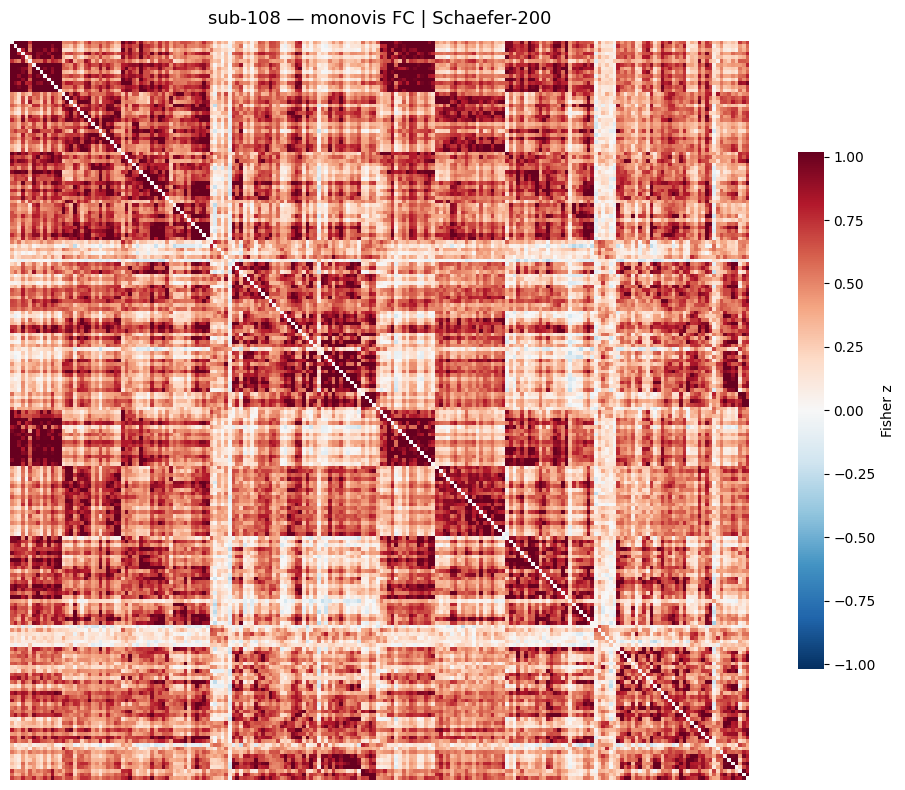


Saved: /pl/active/cowell/studies/monovis/analysis/correlation_matrices/sub-108_ses-S1_task-monovis_atlas-schaefer200_fc-fisherz.csv


In [7]:
# ── ANSWER KEY: full pipeline in one cell ────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fc_helpers import (
    load_confounds, get_parcellation, extract_time_series,
    compute_fc_matrix, save_fc_matrix, plot_fc_matrix, summarise_fc,
)

def run_fc_pipeline(
    bold_path, confounds_path, events_path,
    atlas, n_rois, yeo_networks, atlas_path,
    confound_cols, scrub_threshold,
    t_r, output_dir, subject, session=None, task='rest',
    low_pass=0.10, high_pass=0.01,
    verbose=True,
):
    """
    Run the complete FC pipeline for a single subject/run.

    Returns
    -------
    fc_matrix : np.ndarray  — shape (n_rois, n_rois), Fisher z
    roi_labels : list of str
    out_path   : str         — path to saved CSV
    """
    # 1. Parcellation (load once; reuse across subjects)
    atlas_img, roi_labels = get_parcellation(
        atlas=atlas, n_rois=n_rois,
        yeo_networks=yeo_networks, atlas_path=atlas_path,
    )

    # 2. Confounds
    confounds_array, scrubbed_idx = load_confounds(
        confounds_path, confound_cols,
        scrub_threshold=scrub_threshold,
    )

    # 3. Extract time series
    ts = extract_time_series(
        bold_path, atlas_img, confounds_array, t_r,
        low_pass=low_pass, high_pass=high_pass,
    )

    # 4. Compute FC
    fc = compute_fc_matrix(ts, fisher_z=True)

    # 5. Save
    sess_tag = f'_{session}' if session else ''
    fname    = f'{subject}{sess_tag}_task-{task}_atlas-{atlas}{n_rois}_fc-fisherz.csv'
    out_path = save_fc_matrix(fc, roi_labels, output_dir, filename=fname)

    if verbose:
        summarise_fc(fc, label=f'{subject} | {task}')

    return fc, roi_labels, out_path


# ── Run for the current subject ───────────────────────────────────────────────
fc_matrix, roi_labels, out_path = run_fc_pipeline(
    bold_path        = BOLD_PATH,
    confounds_path   = CONFOUNDS_PATH,
    events_path      = EVENTS_PATH,
    atlas            = ATLAS,
    n_rois           = N_ROIS,
    yeo_networks     = YEO_NETWORKS,
    atlas_path       = ATLAS_PATH,
    confound_cols    = CONFOUND_COLS,
    scrub_threshold  = SCRUB_THRESHOLD,
    t_r              = TR,
    output_dir       = OUTPUT_DIR,
    subject          = SUBJECT,
    session          = SESSION,
    task             = TASK,
)

fig = plot_fc_matrix(
    fc_matrix, labels=roi_labels,
    title=f'{SUBJECT} — {TASK} FC | {ATLAS.capitalize()}-{N_ROIS}',
)
plt.show()

print(f'\nSaved: {out_path}')

### AK-10. Multi-Subject Loop Template

Example of how to scale the pipeline across subjects and sessions.

In [ ]:
# ── ANSWER KEY: multi-subject loop template ───────────────────────────────────
# Load parcellation once — it doesn't change per subject
atlas_img, roi_labels = get_parcellation(
    atlas=ATLAS, n_rois=N_ROIS, yeo_networks=YEO_NETWORKS
)

SUBJECTS = [f'sub-MSC{i:02d}' for i in range(1, 11)]   # sub-MSC01 … sub-MSC10
SESSIONS = [f'ses-func{i:02d}' for i in range(1, 11)]

all_fc = []   # will hold one (n_rois, n_rois) array per subject-session

for sub in SUBJECTS:
    for ses in SESSIONS:
        
        _paths         = build_fmriprep_paths(
            fmriprep_dir = FMRIPREP_DIR,
            subject      = SUBJECT,
            session      = SESSION,
            task         = TASK,
            run          = RUN,
            space        = SPACE,
        )
        bold_path      = _paths['BOLD_PATH']
        confounds_path = _paths['CONFOUNDS_PATH']        
        
        # Skip missing files gracefully
        if not os.path.exists(bold_path) or not os.path.exists(confounds_path):
            print(f'  SKIP {sub} {ses} — file not found')
            continue

        print(f'\nProcessing {sub} | {ses}')
        conf, _ = load_confounds(confounds_path, CONFOUND_COLS, SCRUB_THRESHOLD)
        ts      = extract_time_series(bold_path, atlas_img, conf, TR)
        fc      = compute_fc_matrix(ts, fisher_z=True)

        fname   = f'{sub}_{ses}_task-{TASK}_atlas-{ATLAS}{N_ROIS}_fc-fisherz.csv'
        save_fc_matrix(fc, roi_labels, OUTPUT_DIR, filename=fname)

        all_fc.append(fc)

# Group average FC matrix
if all_fc:
    group_fc = np.stack(all_fc, axis=0).mean(axis=0)   # (n_rois, n_rois)
    print(f'\nGroup FC matrix (n={len(all_fc)}): {group_fc.shape}')
    save_fc_matrix(group_fc, roi_labels, OUTPUT_DIR,
                   filename=f'group_task-{TASK}_atlas-{ATLAS}{N_ROIS}_fc-fisherz.csv')

    fig = plot_fc_matrix(
        group_fc, labels=roi_labels,
        title=f'Group mean FC (n={len(all_fc)}) | {ATLAS.capitalize()}-{N_ROIS}',
    )
    plt.show()

---
## Summary

| Step | Helper function | Key output |
|------|-----------------|------------|
| Motion QC | `plot_fd_trace()` | FD plot, mean FD, % scrubbed |
| Confounds | `load_confounds()` | `confounds_array` (T × regressors) |
| Parcellation | `get_parcellation()` | `atlas_img`, `roi_labels` |
| Time series | `extract_time_series()` | `time_series` (T × n_rois) |
| FC matrix | `compute_fc_matrix()` | `fc_matrix` (n_rois × n_rois, Fisher z) |
| Save | `save_fc_matrix()` | `<subject>_fc-fisherz.csv` |
| Visualise | `plot_fc_matrix()` | Heatmap figure |

**Next steps:** Loop over subjects → stack `all_fc` → group-level GLM, PPI contrast, or graph-theory metrics.